In [1]:
!pip install yfinance ta-lib matplotlib pandas numpy seaborn

[*********************100%***********************]  1 of 1 completed


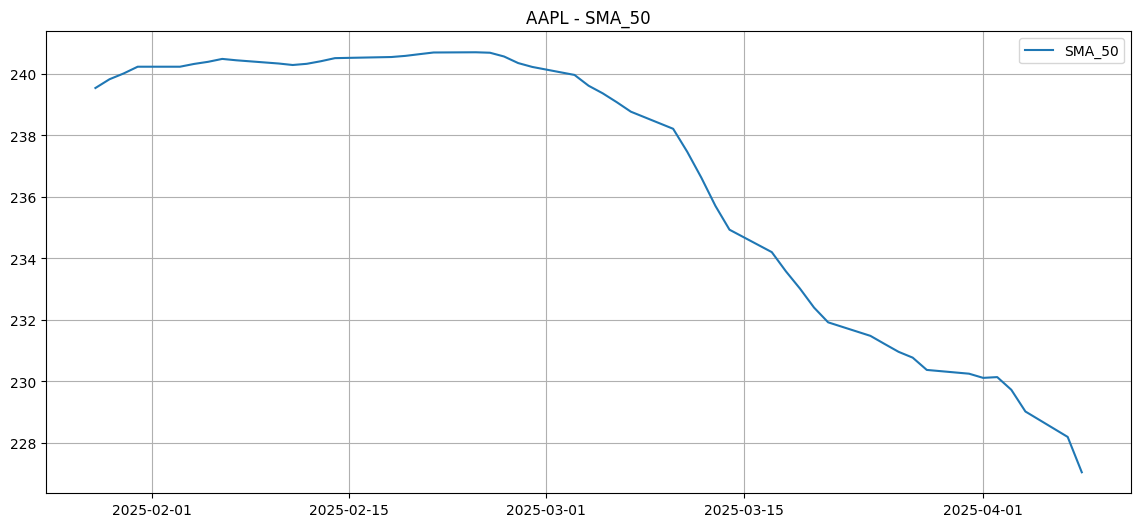

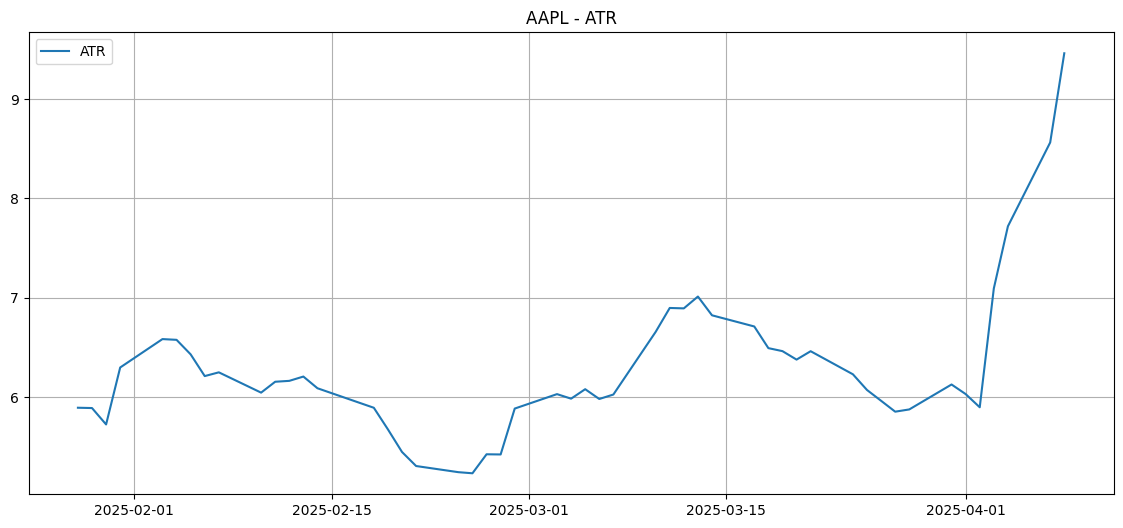

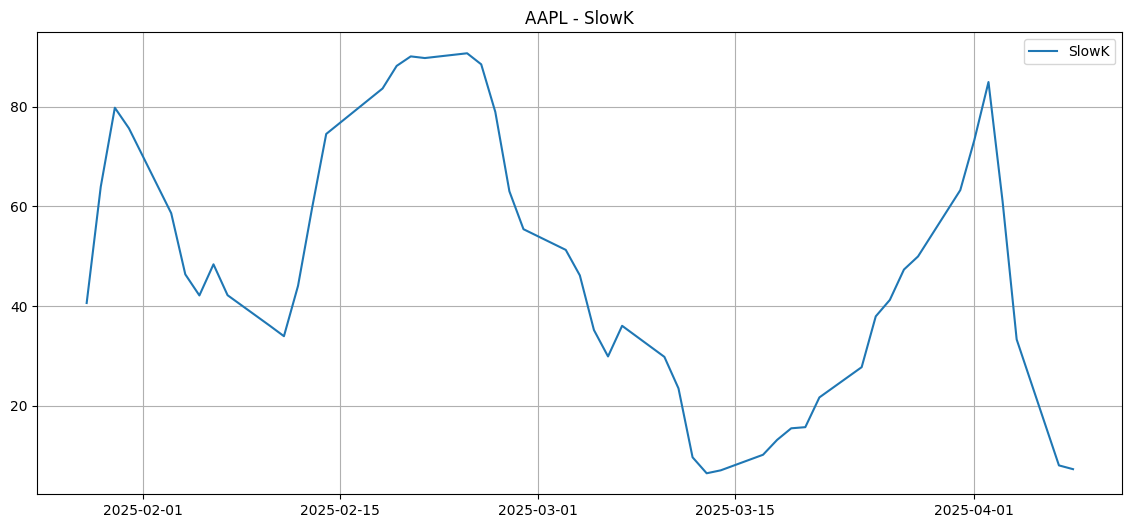

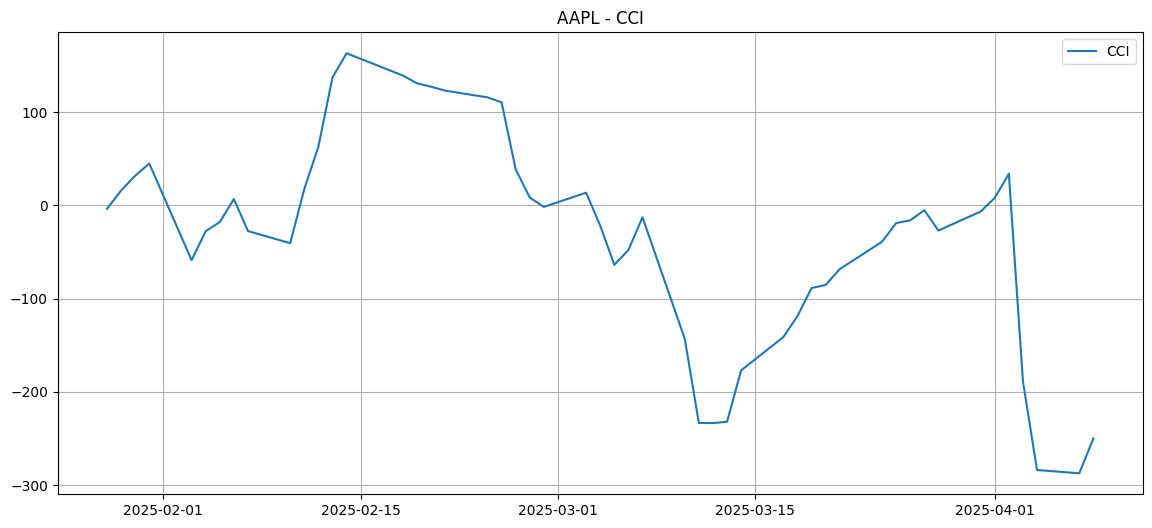

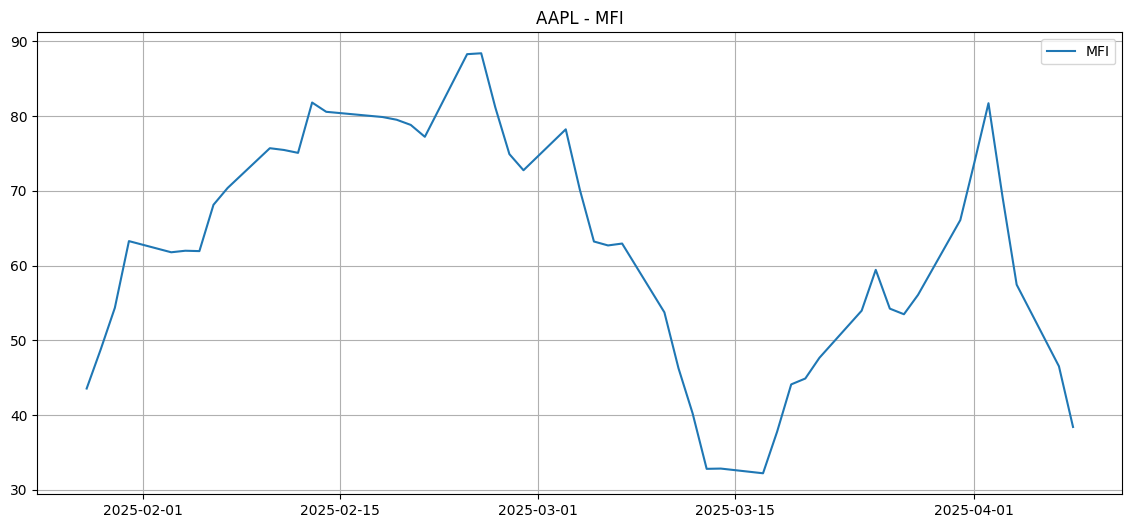

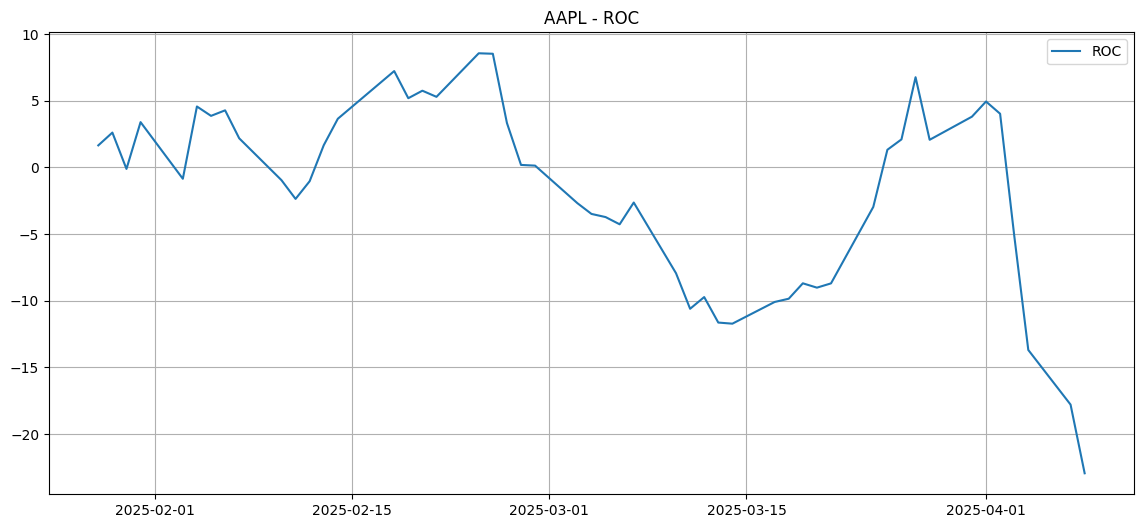

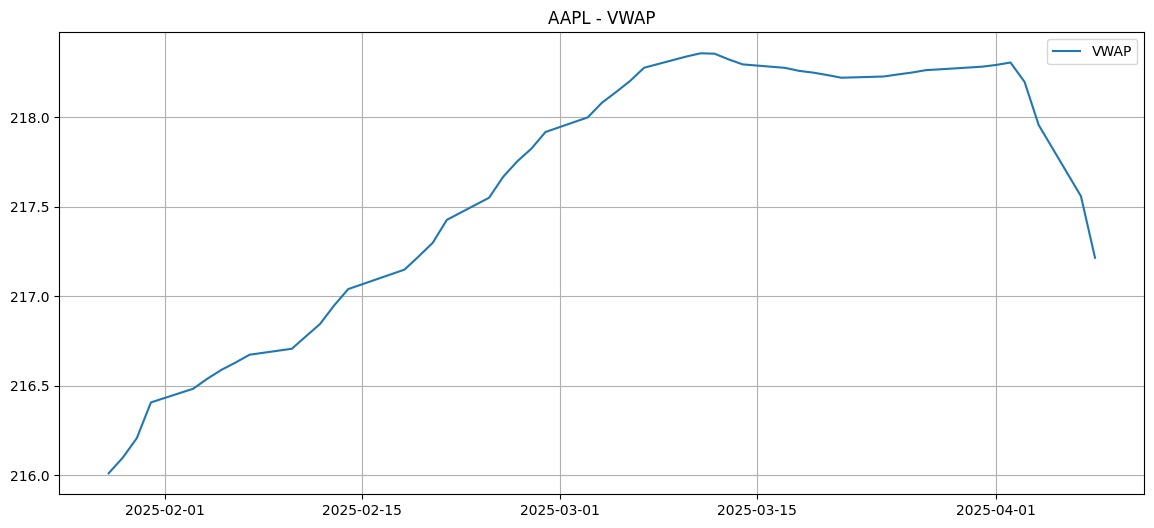

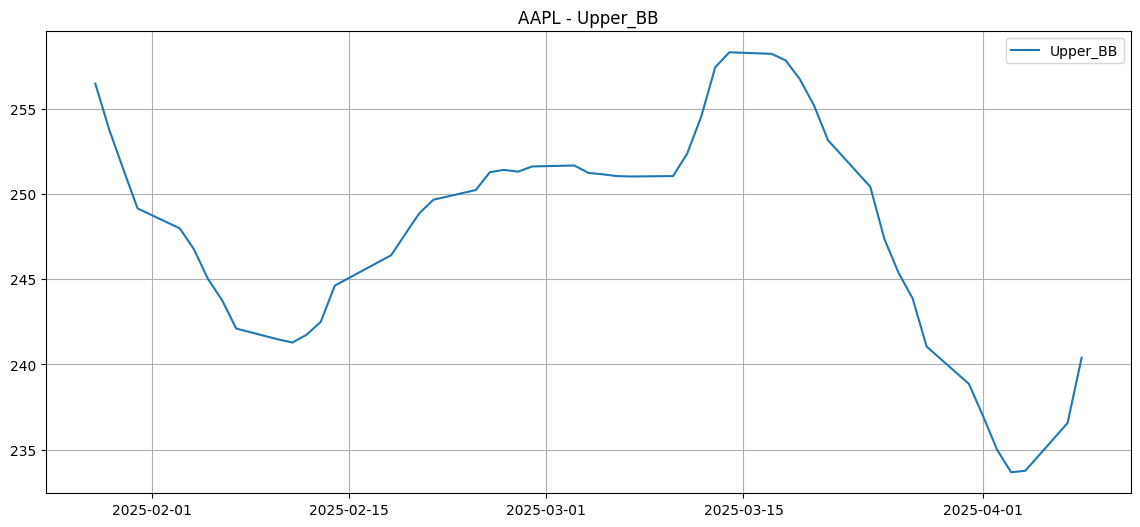

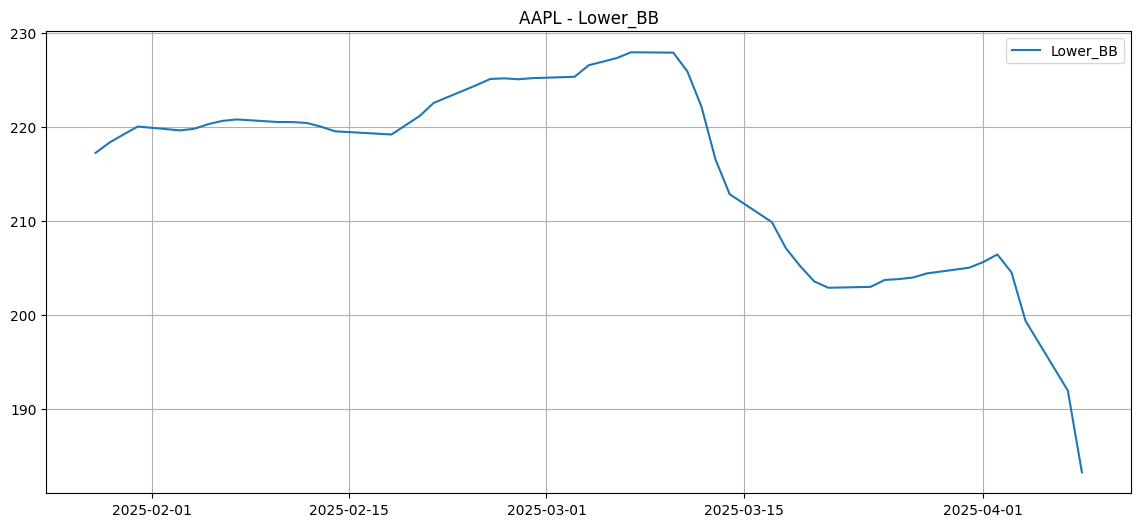

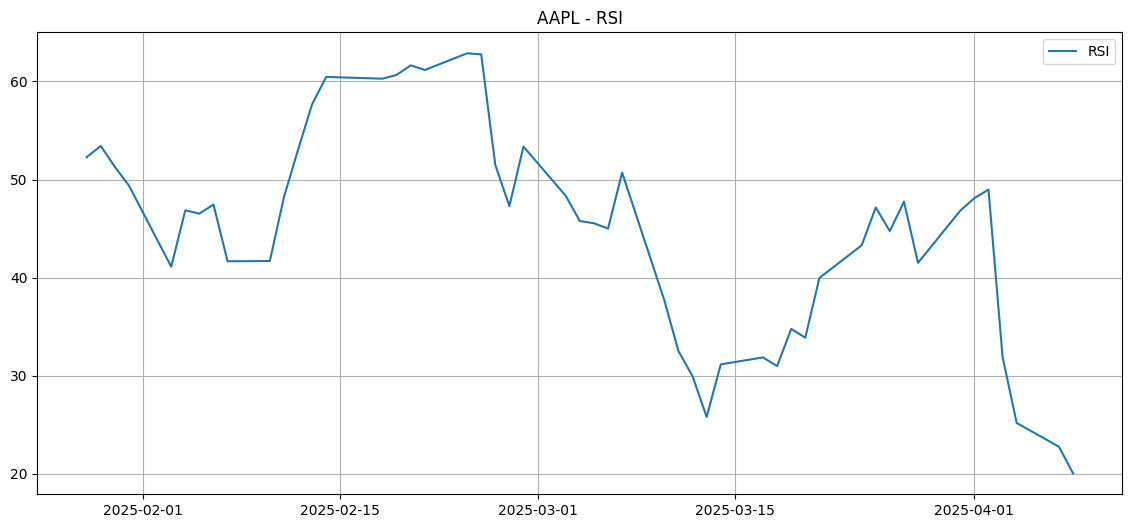

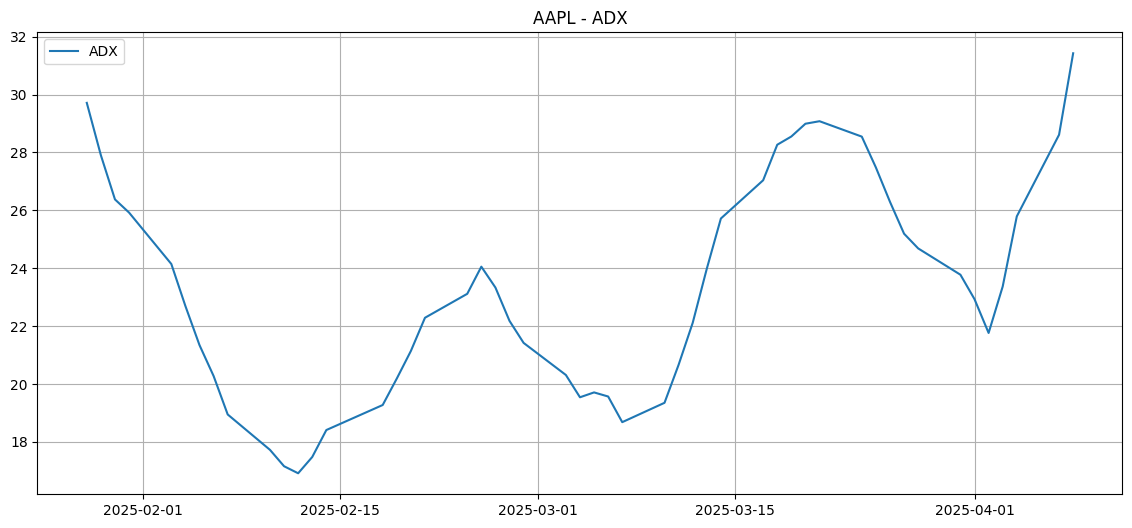

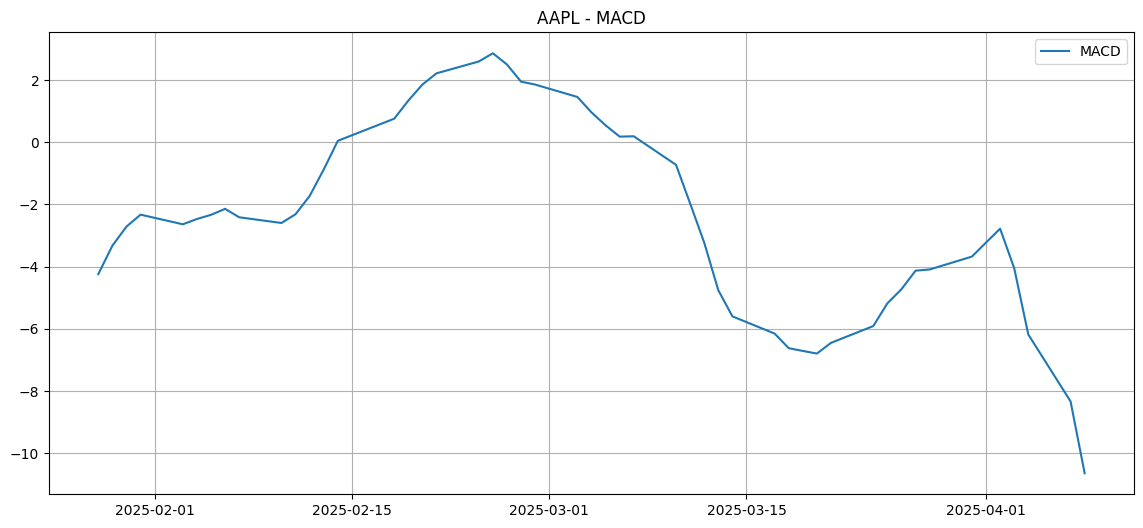

In [2]:
import yfinance as yf
import talib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ 1. 데이터 다운로드 및 결측치 처리
ticker = "AAPL"
df = yf.download(ticker, period="250d", interval="1d", auto_adjust=False)

# 결측치 보간 처리
for col in ["High", "Low", "Close", "Volume"]:
    if df[col].isnull().any().item():
        print(f"[INFO] {col} 컬럼에 결측치가 있습니다. 보간 처리합니다.")
        df[col] = df[col].ffill()

df = df.dropna().astype(float)

# ✅ 2. 기술 지표 계산
high = df["High"].to_numpy().ravel()
low = df["Low"].to_numpy().ravel()
close = df["Close"].to_numpy().ravel()
volume = df["Volume"].to_numpy().ravel()

df["Upper_BB"], df["Middle_BB"], df["Lower_BB"] = talib.BBANDS(close, timeperiod=20)
df["SMA_50"] = talib.SMA(close, timeperiod=50)
df["SMA_200"] = talib.SMA(close, timeperiod=200)
df["RSI"] = talib.RSI(close, timeperiod=14)
df["ADX"] = talib.ADX(high, low, close, timeperiod=14)
df["ATR"] = talib.ATR(high, low, close, timeperiod=14)
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = talib.MACD(close, 12, 26, 9)
df["SlowK"], df["SlowD"] = talib.STOCH(high, low, close, 14, 3, 0, 3, 0)
df["CCI"] = talib.CCI(high, low, close, timeperiod=20)
df["MFI"] = talib.MFI(high, low, close, volume, timeperiod=14)
df["ROC"] = talib.ROC(close, timeperiod=10)

# ✅ VWAP 계산
vwap_numerator = ((df["High"] + df["Low"] + df["Close"]) / 3 * df["Volume"]).cumsum()
vwap_denominator = df["Volume"].cumsum().replace(0, np.nan)
df["VWAP"] = vwap_numerator / vwap_denominator
df["VWAP"] = df["VWAP"].bfill()  # FutureWarning 해결

# ✅ 피보나치 되돌림
max_price = df["Close"].max()
min_price = df["Close"].min()
df["Fib_61.8"] = min_price + (max_price - min_price) * 0.618
df["Fib_38.2"] = min_price + (max_price - min_price) * 0.382

# ✅ 3. 최근 데이터만 추출 (지표 계산 이후!)
df_recent = df.tail(50).copy()

# ✅ 4. 평가 함수 정의
def evaluate_indicator(value, thresholds):
    try:
        if np.isnan(value): return "❌ 평가불가"
    except:
        return "❌ 평가불가"

    if value >= thresholds[2]: return "🔴 고평가 3단계"
    if value >= thresholds[1]: return "🔴 고평가 2단계"
    if value >= thresholds[0]: return "🔴 고평가 1단계"
    if value <= thresholds[5]: return "🟢 저평가 3단계"
    if value <= thresholds[4]: return "🟢 저평가 2단계"
    if value <= thresholds[3]: return "🟢 저평가 1단계"
    return "⚪ 중립"

# ✅ 5. 평가 기준 적용
def apply_thresholds(df_recent):
    result = df_recent.copy()

    # ✅ Bollinger Bands 평가 (NaN 제거 후 평균/분위수 계산)
    bb = df_recent[["Upper_BB", "Lower_BB"]].dropna()
    if not bb.empty:
        thresholds_bb = [
            bb["Upper_BB"].mean(),
            bb["Upper_BB"].quantile(0.75),
            bb["Upper_BB"].max(),
            bb["Lower_BB"].min(),
            bb["Lower_BB"].quantile(0.25),
            bb["Lower_BB"].mean()
        ]
        result["BB_Eval"] = result["Close"].apply(lambda x: evaluate_indicator(x, thresholds_bb))
    
    # ✅ 고정 임계값 지표들
    result["RSI_Eval"] = result["RSI"].apply(lambda x: evaluate_indicator(x, [60, 65, 70, 40, 35, 30]))
    result["ADX_Eval"] = result["ADX"].apply(lambda x: evaluate_indicator(x, [40, 45, 50, 20, 15, 10]))
    result["Stoch_Eval"] = result["SlowK"].apply(lambda x: evaluate_indicator(x, [60, 70, 80, 40, 30, 20]))
    result["CCI_Eval"] = result["CCI"].apply(lambda x: evaluate_indicator(x, [100, 150, 200, -100, -150, -200]))
    result["MFI_Eval"] = result["MFI"].apply(lambda x: evaluate_indicator(x, [60, 70, 80, 40, 30, 20]))

    # ✅ 분위수 기반 평가
    for col in ["MACD", "ROC", "ATR", "SMA_50"]:
        if col in result.columns and result[col].notna().sum() > 0:
            q = result[col].dropna().quantile
            thresholds = [q(0.6), q(0.75), q(1.0), q(0.4), q(0.25), q(0.0)]
            result[f"{col}_Eval"] = result[col].apply(lambda x: evaluate_indicator(x, thresholds))

    return result

df_recent = apply_thresholds(df_recent)

# ✅ 6. 시각화
indicators = ["SMA_50", "ATR", "SlowK", "CCI", "MFI", "ROC", "VWAP", "Upper_BB", "Lower_BB", "RSI", "ADX", "MACD"]

for indicator in indicators:
    if indicator in df_recent.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(df_recent.index, df_recent[indicator].interpolate(), label=indicator)
        plt.title(f"{ticker} - {indicator}")
        plt.grid()
        plt.legend()
        plt.show()

In [3]:
def visualize_with_evaluation(df_recent, indicators, price_col="Close"):
    for indicator in indicators:
        if indicator not in df_recent.columns:
            continue
        
        plt.figure(figsize=(14, 6))

        # 종가 그래프
        if price_col in df_recent.columns:
            plt.plot(df_recent.index, df_recent[price_col], label=price_col, alpha=0.4, linestyle="--")

        # 지표 그래프
        plt.plot(df_recent.index, df_recent[indicator], label=indicator, color="blue")

        # 현재값
        current_value = df_recent[indicator].iloc[-1]
        current_date = df_recent.index[-1]
        eval_col = f"{indicator}_Eval"
        current_eval = df_recent[eval_col].iloc[-1] if eval_col in df_recent.columns else "❓"

        # 현재값에 표시
        plt.scatter(current_date, current_value, color="red", zorder=5)
        plt.text(current_date, current_value, f"{indicator}\n{current_value:.2f}\n{current_eval}",
                 fontsize=12, ha='left', va='bottom',
                 bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'))

        plt.title(f"{ticker} - {indicator} (현재값 + 평가)")
        plt.grid()
        plt.legend()
        plt.tight_layout()
        plt.show()

In [4]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로 지정 (Windows 기준, 나눔고딕 예시)
font_path = "C:/Windows/Fonts/malgun.ttf"  # '맑은 고딕' 사용
font_prop = fm.FontProperties(fname=font_path)

plt.rc("font", family=font_prop.get_name())  # Matplotlib 기본 폰트 설정

In [5]:
import yfinance as yf
import talib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
ticker = "AAPL"  # 애플(AAPL) 예시
df = yf.download(ticker, period="250d", interval="1d")  # 250일 데이터 다운로드
df_recent = df.tail(50)  # 최근 50일 데이터만 사용
df_recent.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-28,237.998322,239.926210,230.556507,230.596471,75707600
2025-01-29,239.097122,239.596573,233.752992,233.862872,45486100
2025-01-30,237.329056,240.525538,236.949483,238.407871,55658300
2025-01-31,235.740814,246.918527,233.183628,246.918527,101075100
2025-02-03,227.759583,231.575395,225.452122,229.737419,73063300


In [7]:
# 모든 데이터를 float로 변환
df["High"] = df["High"].astype(float)
df["Low"] = df["Low"].astype(float)
df["Close"] = df["Close"].astype(float)
df["Volume"] = df["Volume"].astype(float)

# 1차원 배열로 변환
high = df["High"].values.ravel()
low = df["Low"].values.ravel()
close = df["Close"].values.ravel()
volume = df["Volume"].values.ravel()

In [8]:
# 📌 볼린저 밴드 (Bollinger Bands)
df["Upper_BB"], df["Middle_BB"], df["Lower_BB"] = talib.BBANDS(close, timeperiod=20)

# 📌 이동 평균선 (SMA)
df["SMA_50"] = talib.SMA(close, timeperiod=50)
df["SMA_200"] = talib.SMA(close, timeperiod=200)

# 📌 RSI (상대강도지수)
df["RSI"] = talib.RSI(close, timeperiod=14)

# 📌 ADX (평균 방향성 지수)
df["ADX"] = talib.ADX(high, low, close, timeperiod=14)

# 📌 ATR (평균 진폭)
df["ATR"] = talib.ATR(high, low, close, timeperiod=14)

# 📌 MACD (이동평균 수렴·확산 지수)
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)

# 📌 스토캐스틱 오실레이터 (Stochastic Oscillator)
df["SlowK"], df["SlowD"] = talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)

# 📌 CCI (상품채널지수)
df["CCI"] = talib.CCI(high, low, close, timeperiod=20)

# 📌 MFI (자금 흐름 지수)
df["MFI"] = talib.MFI(high, low, close, volume, timeperiod=14)

# 📌 ROC (가격 변동률)
df["ROC"] = talib.ROC(close, timeperiod=10)

# 📌 VWAP (거래량 가중 평균 가격)
df["VWAP"] = ((df["High"] + df["Low"] + df["Close"]) / 3 * df["Volume"]).cumsum() / df["Volume"].cumsum()

# 📌 피보나치 되돌림 계산
max_price = df["Close"].max()
min_price = df["Close"].min()
df["Fib_61.8"] = min_price + (max_price - min_price) * 0.618
df["Fib_38.2"] = min_price + (max_price - min_price) * 0.382

In [9]:
# 평가 기준 설정 함수
def evaluate_indicator(value, thresholds):
    if value >= thresholds[2]:
        return "🔴 고평가 3단계"
    elif value >= thresholds[1]:
        return "🔴 고평가 2단계"
    elif value >= thresholds[0]:
        return "🔴 고평가 1단계"
    elif value <= thresholds[5]:
        return "🟢 저평가 3단계"
    elif value <= thresholds[4]:
        return "🟢 저평가 2단계"
    elif value <= thresholds[3]:
        return "🟢 저평가 1단계"
    else:
        return "⚪ 중립"

# 📌 볼린저 밴드 평가 기준
thresholds_bb = [df_recent["Upper_BB"].mean(), df_recent["Upper_BB"].quantile(0.75), df_recent["Upper_BB"].max(),
                 df_recent["Lower_BB"].min(), df_recent["Lower_BB"].quantile(0.25), df_recent["Lower_BB"].mean()]
df_recent["BB_Eval"] = df_recent["Close"].apply(lambda x: evaluate_indicator(x, thresholds_bb))

# 📌 RSI 평가 기준
thresholds_rsi = [70, 65, 60, 40, 35, 30]
df_recent["RSI_Eval"] = df_recent["RSI"].apply(lambda x: evaluate_indicator(x, thresholds_rsi))

# 📌 ADX 평가 기준
thresholds_adx = [50, 45, 40, 20, 15, 10]
df_recent["ADX_Eval"] = df_recent["ADX"].apply(lambda x: evaluate_indicator(x, thresholds_adx))

# 📌 MACD 평가 기준
thresholds_macd = [df_recent["MACD"].quantile(0.75), df_recent["MACD"].quantile(0.6), df_recent["MACD"].median(),
                   df_recent["MACD"].median(), df_recent["MACD"].quantile(0.4), df_recent["MACD"].quantile(0.25)]
df_recent["MACD_Eval"] = df_recent["MACD"].apply(lambda x: evaluate_indicator(x, thresholds_macd))

# 📌 SMA 평가 기준
thresholds_sma = [df_recent["SMA"].quantile(0.75), df_recent["SMA"].quantile(0.6), df_recent["SMA"].median(),
                   df_recent["SMA"].median(), df_recent["SMA"].quantile(0.4), df_recent["SMA"].quantile(0.25)]
df_recent["SMA_Eval"] = df_recent["SMA"].apply(lambda x: evaluate_indicator(x, thresholds_sma))

# 📌 ATR 평가 기준
thresholds_atr = [df_recent["ATR"].quantile(0.75), df_recent["ATR"].quantile(0.6), df_recent["ATR"].median(),
                   df_recent["ATR"].median(), df_recent["ATR"].quantile(0.4), df_recent["ATR"].quantile(0.25)]
df_recent["ATR_Eval"] = df_recent["ATR"].apply(lambda x: evaluate_indicator(x, thresholds_atr))

# 📌 스토캐스틱 오실레이터 평가 기준
thresholds_stoch = [80, 70, 60, 40, 30, 20]
df_recent["Stoch_Eval"] = df_recent["SlowK"].apply(lambda x: evaluate_indicator(x, thresholds_stoch))

# 📌 CCI 평가 기준
thresholds_cci = [200, 150, 100, -100, -150, -200]
df_recent["CCI_Eval"] = df_recent["CCI"].apply(lambda x: evaluate_indicator(x, thresholds_cci))

# 📌 MFI 평가 기준
thresholds_mfi = [80, 70, 60, 40, 30, 20]
df_recent["MFI_Eval"] = df_recent["MFI"].apply(lambda x: evaluate_indicator(x, thresholds_mfi))

# 📌 ROC 평가 기준
thresholds_roc = [df_recent["ROC"].quantile(0.75), df_recent["ROC"].quantile(0.6), df_recent["ROC"].median(),
                   df_recent["ROC"].median(), df_recent["ROC"].quantile(0.4), df_recent["ROC"].quantile(0.25)]
df_recent["ROC_Eval"] = df_recent["ROC"].apply(lambda x: evaluate_indicator(x, thresholds_roc))

# 📌 VWAP 평가 기준
thresholds_vwap = [df_recent["VWAP"].quantile(0.75), df_recent["VWAP"].quantile(0.6), df_recent["VWAP"].median(),
                   df_recent["VWAP"].median(), df_recent["VWAP"].quantile(0.4), df_recent["VWAP"].quantile(0.25)]
df_recent["VWAP_Eval"] = df_recent["VWAP"].apply(lambda x: evaluate_indicator(x, thresholds_vwap))

# 📌 지표 시각화
indicators = ["SMA", "ATR", "SlowK", "CCI", "MFI", "ROC", "VWAP", "Upper_BB", "Lower_BB", "RSI", "ADX", "MACD"]
for indicator in indicators:
    plt.figure(figsize=(14, 6))
    plt.plot(df_recent.index, df_recent[indicator], label=indicator, color=np.random.rand(3,))
    plt.title(f"{ticker} {indicator}")
    plt.legend()
    plt.show()

KeyError: 'Upper_BB'

In [10]:
df.columns

MultiIndex([(      'Close', 'AAPL'),
            (       'High', 'AAPL'),
            (        'Low', 'AAPL'),
            (       'Open', 'AAPL'),
            (     'Volume', 'AAPL'),
            (   'Upper_BB',     ''),
            (  'Middle_BB',     ''),
            (   'Lower_BB',     ''),
            (     'SMA_50',     ''),
            (    'SMA_200',     ''),
            (        'RSI',     ''),
            (        'ADX',     ''),
            (        'ATR',     ''),
            (       'MACD',     ''),
            ('MACD_Signal',     ''),
            (  'MACD_Hist',     ''),
            (      'SlowK',     ''),
            (      'SlowD',     ''),
            (        'CCI',     ''),
            (        'MFI',     ''),
            (        'ROC',     ''),
            (       'VWAP',     ''),
            (   'Fib_61.8',     ''),
            (   'Fib_38.2',     '')],
           names=['Price', 'Ticker'])

In [11]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

KeyError: 'Upper_BB'

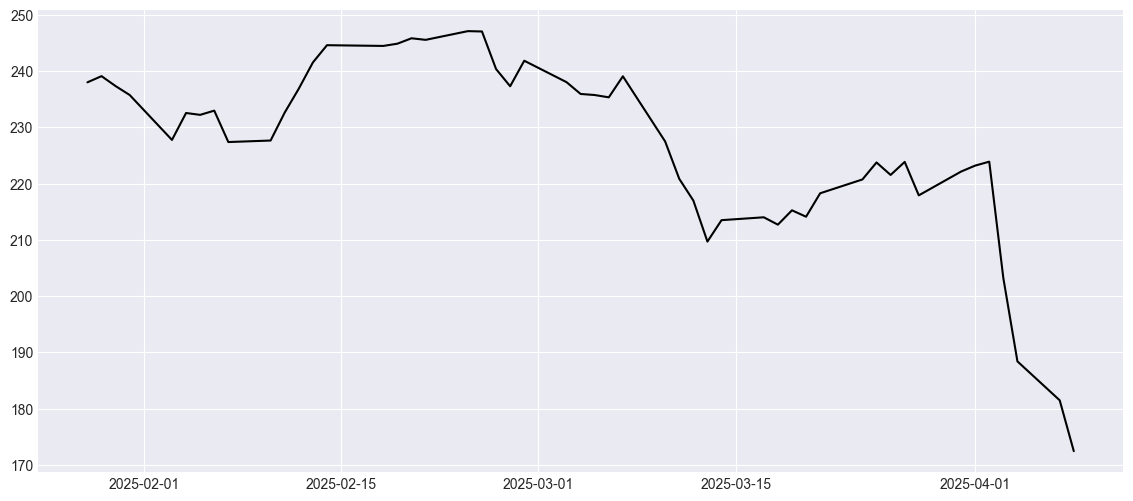

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black")
plt.plot(df_recent.index, df_recent["Upper_BB"], linestyle="dotted", color="red", label="Upper BB")
plt.plot(df_recent.index, df_recent["Lower_BB"], linestyle="dotted", color="green", label="Lower BB")
plt.title(f"{ticker} 주가 & 볼린저 밴드")
plt.legend()
plt.show()

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black")
plt.plot(df_recent.index, df_recent["SMA_50"], label="SMA 50", color="orange")
plt.plot(df_recent.index, df_recent["SMA_200"], label="SMA 200", color="purple")
plt.title(f"{ticker} 이동 평균선")
plt.legend()
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black", alpha=0.3)
ax1.set_ylabel("Close Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(df_recent.index, df_recent["RSI"], label="RSI", color="blue")
ax2.axhline(y=70, color="red", linestyle="dashed")  # 과매수선
ax2.axhline(y=30, color="green", linestyle="dashed")  # 과매도선
ax2.set_ylabel("RSI", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title(f"{ticker} RSI 지표 & 종가")
plt.legend()
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black", alpha=0.3)
ax1.set_ylabel("Close Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(df_recent.index, df_recent["ADX"], label="ADX", color="purple")
ax2.axhline(y=25, color="gray", linestyle="dashed")  # 약한 추세
ax2.axhline(y=50, color="red", linestyle="dashed")  # 강한 추세
ax2.set_ylabel("ADX", color="purple")
ax2.tick_params(axis="y", labelcolor="purple")

plt.title(f"{ticker} ADX 지표 & 종가")
plt.legend()
plt.show()


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black", alpha=0.3)
ax1.set_ylabel("Close Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(df_recent.index, df_recent["ATR"], label="ATR", color="brown")
ax2.set_ylabel("ATR", color="brown")
ax2.tick_params(axis="y", labelcolor="brown")

plt.title(f"{ticker} ATR 지표 & 종가")
plt.legend()
plt.show()


KeyError: 'MACD'

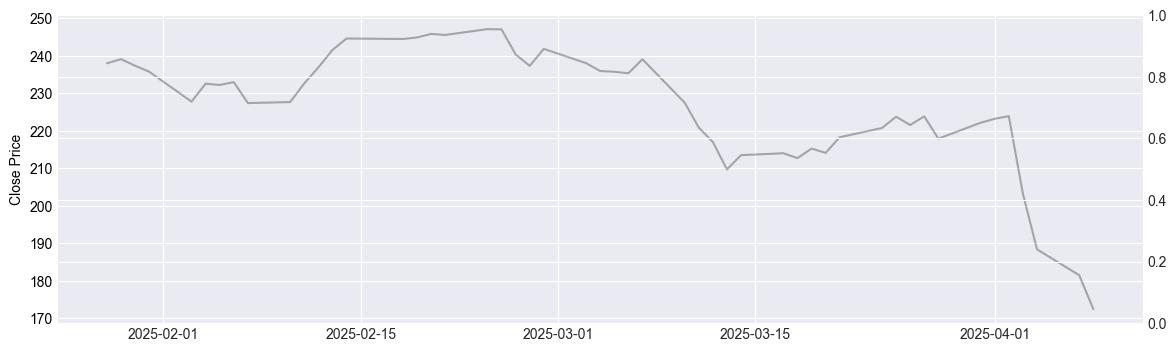

In [13]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black", alpha=0.3)
ax1.set_ylabel("Close Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(df_recent.index, df_recent["MACD"], label="MACD", color="blue")
ax2.plot(df_recent.index, df_recent["MACD_Signal"], label="MACD Signal", color="red")
ax2.bar(df_recent.index, df_recent["MACD_Hist"], label="MACD Histogram", color="gray", alpha=0.5)
ax2.axhline(y=0, color="black", linestyle="dashed")  # 기준선
ax2.set_ylabel("MACD", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title(f"{ticker} MACD 지표 & 종가")
plt.legend()
plt.show()


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black", alpha=0.3)
ax1.set_ylabel("Close Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(df_recent.index, df_recent["SlowK"], label="SlowK", color="blue")
ax2.plot(df_recent.index, df_recent["SlowD"], label="SlowD", color="red")
ax2.axhline(y=80, color="red", linestyle="dashed")  # 과매수
ax2.axhline(y=20, color="green", linestyle="dashed")  # 과매도
ax2.set_ylabel("Stochastic Oscillator", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title(f"{ticker} 스토캐스틱 오실레이터 & 종가")
plt.legend()
plt.show()


In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black", alpha=0.3)
ax1.set_ylabel("Close Price", color="black")
ax1.tick_params(axis="y", labelcolor="black")

ax2 = ax1.twinx()
ax2.plot(df_recent.index, df_recent["CCI"], label="CCI", color="blue")
ax2.axhline(y=100, color="red", linestyle="dashed")  # 과매수
ax2.axhline(y=-100, color="green", linestyle="dashed")  # 과매도
ax2.set_ylabel("CCI", color="blue")
ax2.tick_params(axis="y", labelcolor="blue")

plt.title(f"{ticker} CCI 지표 & 종가")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df_recent.index, df_recent["Close"], label="Close Price", color="black")
plt.axhline(y=df["Fib_61.8"].iloc[-1], color="red", linestyle="dashed", label="Fib 61.8%")
plt.axhline(y=df["Fib_38.2"].iloc[-1], color="green", linestyle="dashed", label="Fib 38.2%")
plt.title(f"{ticker} 피보나치 되돌림 & 종가")
plt.legend()
plt.show()

In [ ]:
import yfinance as yf
import talib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ✅ 1. 데이터 다운로드 및 전처리
ticker = "AAPL"
df = yf.download(ticker, period="250d", interval="1d")

# 결측치 확인 및 처리
for col in ["High", "Low", "Close", "Volume"]:
    if df[col].isnull().any():
        print(f"{col} 컬럼에 결측치가 있습니다. 처리합니다.")
        df[col] = df[col].fillna(method='ffill')

df = df.dropna().copy()
df = df.astype(float)
df_recent = df.tail(50)

# ✅ 2. 기술 지표 계산
high, low, close, volume = df["High"].values, df["Low"].values, df["Close"].values, df["Volume"].values

df["Upper_BB"], df["Middle_BB"], df["Lower_BB"] = talib.BBANDS(close, timeperiod=20)
df["SMA_50"] = talib.SMA(close, timeperiod=50)
df["SMA_200"] = talib.SMA(close, timeperiod=200)
df["RSI"] = talib.RSI(close, timeperiod=14)
df["ADX"] = talib.ADX(high, low, close, timeperiod=14)
df["ATR"] = talib.ATR(high, low, close, timeperiod=14)
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = talib.MACD(close, 12, 26, 9)
df["SlowK"], df["SlowD"] = talib.STOCH(high, low, close, 14, 3, 0, 3, 0)
df["CCI"] = talib.CCI(high, low, close, timeperiod=20)
df["MFI"] = talib.MFI(high, low, close, volume, timeperiod=14)
df["ROC"] = talib.ROC(close, timeperiod=10)

# ✅ VWAP (안정적인 계산)
vwap_numerator = ((df["High"] + df["Low"] + df["Close"]) / 3 * df["Volume"]).cumsum()
vwap_denominator = df["Volume"].cumsum().replace(0, np.nan)
df["VWAP"] = vwap_numerator / vwap_denominator
df["VWAP"].fillna(method="bfill", inplace=True)

# ✅ 피보나치 되돌림 계산
max_price = df["Close"].max()
min_price = df["Close"].min()
df["Fib_61.8"] = min_price + (max_price - min_price) * 0.618
df["Fib_38.2"] = min_price + (max_price - min_price) * 0.382

# ✅ 3. 평가 함수 정의
def evaluate_indicator(value, thresholds):
    if np.isnan(value):
        return "❌ 평가불가"
    if value >= thresholds[2]:
        return "🔴 고평가 3단계"
    elif value >= thresholds[1]:
        return "🔴 고평가 2단계"
    elif value >= thresholds[0]:
        return "🔴 고평가 1단계"
    elif value <= thresholds[5]:
        return "🟢 저평가 3단계"
    elif value <= thresholds[4]:
        return "🟢 저평가 2단계"
    elif value <= thresholds[3]:
        return "🟢 저평가 1단계"
    else:
        return "⚪ 중립"

# ✅ 4. 지표별 평가 기준 및 적용

# 볼린저 밴드 평가 기준
thresholds_bb = [
    df_recent["Upper_BB"].mean(),
    df_recent["Upper_BB"].quantile(0.75),
    df_recent["Upper_BB"].max(),
    df_recent["Lower_BB"].min(),
    df_recent["Lower_BB"].quantile(0.25),
    df_recent["Lower_BB"].mean()
]
df_recent["BB_Eval"] = df_recent["Close"].apply(lambda x: evaluate_indicator(x, thresholds_bb))

# RSI 평가 기준
thresholds_rsi = [60, 65, 70, 40, 35, 30]
df_recent["RSI_Eval"] = df_recent["RSI"].apply(lambda x: evaluate_indicator(x, thresholds_rsi))

# ADX 평가 기준
thresholds_adx = [40, 45, 50, 20, 15, 10]
df_recent["ADX_Eval"] = df_recent["ADX"].apply(lambda x: evaluate_indicator(x, thresholds_adx))

# 스토캐스틱 SlowK 기준
thresholds_stoch = [60, 70, 80, 40, 30, 20]
df_recent["Stoch_Eval"] = df_recent["SlowK"].apply(lambda x: evaluate_indicator(x, thresholds_stoch))

# CCI
thresholds_cci = [100, 150, 200, -100, -150, -200]
df_recent["CCI_Eval"] = df_recent["CCI"].apply(lambda x: evaluate_indicator(x, thresholds_cci))

# MFI
thresholds_mfi = [60, 70, 80, 40, 30, 20]
df_recent["MFI_Eval"] = df_recent["MFI"].apply(lambda x: evaluate_indicator(x, thresholds_mfi))

# MACD
q_macd = df_recent["MACD"].quantile
thresholds_macd = [q_macd(0.6), q_macd(0.75), q_macd(1.0), q_macd(0.4), q_macd(0.25), q_macd(0.0)]
df_recent["MACD_Eval"] = df_recent["MACD"].apply(lambda x: evaluate_indicator(x, thresholds_macd))

# ROC
q_roc = df_recent["ROC"].quantile
thresholds_roc = [q_roc(0.6), q_roc(0.75), q_roc(1.0), q_roc(0.4), q_roc(0.25), q_roc(0.0)]
df_recent["ROC_Eval"] = df_recent["ROC"].apply(lambda x: evaluate_indicator(x, thresholds_roc))

# SMA_50
q_sma = df_recent["SMA_50"].quantile
thresholds_sma = [q_sma(0.6), q_sma(0.75), q_sma(1.0), q_sma(0.4), q_sma(0.25), q_sma(0.0)]
df_recent["SMA_Eval"] = df_recent["SMA_50"].apply(lambda x: evaluate_indicator(x, thresholds_sma))

# ATR
q_atr = df_recent["ATR"].quantile
thresholds_atr = [q_atr(0.6), q_atr(0.75), q_atr(1.0), q_atr(0.4), q_atr(0.25), q_atr(0.0)]
df_recent["ATR_Eval"] = df_recent["ATR"].apply(lambda x: evaluate_indicator(x, thresholds_atr))

# ✅ 5. 지표 시각화
indicators = ["SMA_50", "ATR", "SlowK", "CCI", "MFI", "ROC", "VWAP", "Upper_BB", "Lower_BB", "RSI", "ADX", "MACD"]

for indicator in indicators:
    if indicator in df_recent.columns:
        plt.figure(figsize=(14, 6))
        plt.plot(df_recent.index, df_recent[indicator].interpolate(), label=indicator)
        plt.title(f"{ticker} - {indicator}")
        plt.legend()
        plt.grid()
        plt.show()

In [14]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# talib 대신 ta 라이브러리 사용 (talib이 설치되어 있다면 그대로 사용 가능)
try:
    import talib
    talib_installed = True
except ImportError:
    import ta
    talib_installed = False
    print("talib을 찾을 수 없어 ta 라이브러리를 대신 사용합니다.")

# ✅ 1. 데이터 다운로드 및 전처리
ticker = "AAPL"  # 애플(AAPL) 예시
try:
    df = yf.download(ticker, period="250d", interval="1d")  # 250일 데이터 다운로드
    if df.empty:
        raise ValueError(f"{ticker}에 대한 데이터를 가져올 수 없습니다.")
except Exception as e:
    print(f"데이터 다운로드 중 오류: {e}")
    exit(1)

df_recent = df.tail(50)  # 최근 50일 데이터만 사용

# 모든 데이터를 float로 변환 및 결측치 확인
for col in ['High', 'Low', 'Close', 'Volume']:
    df[col] = df[col].astype(float)
    # Series.isnull().any()는 불리언 값을 직접 반환하므로 .item() 불필요
    if df[col].isnull().any():
        print(f"{col} 컬럼에 결측치가 있습니다. 처리합니다.")
        df[col] = df[col].fillna(method='ffill')  # 결측치 처리

# 1차원 배열로 변환
high = np.array(df["High"]).ravel()
low = np.array(df["Low"]).ravel()
close = np.array(df["Close"]).ravel()
volume = np.array(df["Volume"]).ravel()

# 지표 계산 함수 (talib 또는 ta 사용)
def calculate_indicators(df, high, low, close, volume):
    result_df = df.copy()  # 결과용 데이터프레임 복사
    
    if talib_installed:
        # 📌 볼린저 밴드 (Bollinger Bands)
        result_df["Upper_BB"], result_df["Middle_BB"], result_df["Lower_BB"] = talib.BBANDS(close, timeperiod=20)
        
        # 📌 이동 평균선 (SMA)
        result_df["SMA_50"] = talib.SMA(close, timeperiod=50)
        result_df["SMA_200"] = talib.SMA(close, timeperiod=200)
        
        # 📌 RSI (상대강도지수)
        result_df["RSI"] = talib.RSI(close, timeperiod=14)
        
        # 📌 ADX (평균 방향성 지수)
        result_df["ADX"] = talib.ADX(high, low, close, timeperiod=14)
        
        # 📌 ATR (평균 진폭)
        result_df["ATR"] = talib.ATR(high, low, close, timeperiod=14)
        
        # 📌 MACD (이동평균 수렴·확산 지수)
        result_df["MACD"], result_df["MACD_Signal"], result_df["MACD_Hist"] = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
        
        # 📌 스토캐스틱 오실레이터 (Stochastic Oscillator)
        result_df["SlowK"], result_df["SlowD"] = talib.STOCH(high, low, close, fastk_period=14, slowk_period=3, slowd_period=3)
        
        # 📌 CCI (상품채널지수)
        result_df["CCI"] = talib.CCI(high, low, close, timeperiod=20)
        
        # 📌 MFI (자금 흐름 지수)
        result_df["MFI"] = talib.MFI(high, low, close, volume, timeperiod=14)
        
        # 📌 ROC (가격 변동률)
        result_df["ROC"] = talib.ROC(close, timeperiod=10)
    else:
        # ta 라이브러리를 사용한 대체 구현
        # 볼린저 밴드
        indicator_bb = ta.volatility.BollingerBands(close=result_df["Close"], window=20, window_dev=2)
        result_df["Upper_BB"] = indicator_bb.bollinger_hband()
        result_df["Middle_BB"] = indicator_bb.bollinger_mavg()
        result_df["Lower_BB"] = indicator_bb.bollinger_lband()
        
        # SMA
        result_df["SMA_50"] = ta.trend.sma_indicator(result_df["Close"], window=50)
        result_df["SMA_200"] = ta.trend.sma_indicator(result_df["Close"], window=200)
        
        # RSI
        result_df["RSI"] = ta.momentum.rsi(result_df["Close"], window=14)
        
        # ADX
        result_df["ADX"] = ta.trend.adx(result_df["High"], result_df["Low"], result_df["Close"], window=14)
        
        # ATR
        result_df["ATR"] = ta.volatility.average_true_range(result_df["High"], result_df["Low"], result_df["Close"], window=14)
        
        # MACD
        macd = ta.trend.MACD(result_df["Close"], window_slow=26, window_fast=12, window_sign=9)
        result_df["MACD"] = macd.macd()
        result_df["MACD_Signal"] = macd.macd_signal()
        result_df["MACD_Hist"] = macd.macd_diff()
        
        # 스토캐스틱
        stoch = ta.momentum.StochasticOscillator(result_df["High"], result_df["Low"], result_df["Close"], window=14, smooth_window=3)
        result_df["SlowK"] = stoch.stoch()
        result_df["SlowD"] = stoch.stoch_signal()
        
        # CCI
        result_df["CCI"] = ta.trend.cci(result_df["High"], result_df["Low"], result_df["Close"], window=20)
        
        # MFI
        result_df["MFI"] = ta.volume.money_flow_index(result_df["High"], result_df["Low"], result_df["Close"], result_df["Volume"], window=14)
        
        # ROC
        result_df["ROC"] = ta.momentum.roc(result_df["Close"], window=10)
    
    # 📌 VWAP (거래량 가중 평균 가격)
    result_df["VWAP"] = ((result_df["High"] + result_df["Low"] + result_df["Close"]) / 3 * result_df["Volume"]).cumsum() / result_df["Volume"].cumsum()
    
    # 📌 피보나치 되돌림 계산
    max_price = float(result_df["Close"].max())
    min_price = float(result_df["Close"].min())
    result_df["Fib_61.8"] = min_price + (max_price - min_price) * 0.618
    result_df["Fib_38.2"] = min_price + (max_price - min_price) * 0.382
    
    # NaN 값 처리
    for col in result_df.columns:
        if result_df[col].isnull().any():
            result_df[col] = result_df[col].fillna(method='ffill').fillna(method='bfill')
    
    return result_df

# 지표 계산 실행
df = calculate_indicators(df, high, low, close, volume)
df_recent = df.tail(50)  # 최근 50일 데이터만 사용 (지표 계산 후 다시 추출)

# ✅ 평가 기준 설정 함수 (보다 명시적인 조건 확인)
def evaluate_indicator(value, thresholds):
    # 상위 레벨 임계값이 먼저 오는지 확인 (내림차순 여부)
    descending = thresholds[0] > thresholds[-1]
    
    # 입력값이 스칼라인지 확인
    if isinstance(value, (pd.Series, np.ndarray)):
        value = float(value)  # 명시적으로 float로 변환
    
    if descending:
        # 내림차순 임계값 (일반적인 RSI, 스토캐스틱 등)
        if value >= thresholds[0]:
            return "🔴 고평가 3단계"
        elif value >= thresholds[1]:
            return "🔴 고평가 2단계"
        elif value >= thresholds[2]:
            return "🔴 고평가 1단계"
        elif value <= thresholds[5]:
            return "🟢 저평가 3단계"
        elif value <= thresholds[4]:
            return "🟢 저평가 2단계"
        elif value <= thresholds[3]:
            return "🟢 저평가 1단계"
        else:
            return "⚪ 중립"
    else:
        # 오름차순 임계값 (데이터 기반 임계값)
        if value >= thresholds[5]:
            return "🔴 고평가 3단계"
        elif value >= thresholds[4]:
            return "🔴 고평가 2단계"
        elif value >= thresholds[3]:
            return "🔴 고평가 1단계"
        elif value <= thresholds[0]:
            return "🟢 저평가 3단계"
        elif value <= thresholds[1]:
            return "🟢 저평가 2단계"
        elif value <= thresholds[2]:
            return "🟢 저평가 1단계"
        else:
            return "⚪ 중립"

# 평가 함수 적용
try:
    # ✅ 미리 정의된 임계값 (RSI, 스토캐스틱, CCI, MFI)
    # 내림차순 임계값 (높을수록 과매수)
    thresholds_rsi = [70, 65, 60, 40, 35, 30]
    thresholds_stoch = [80, 70, 60, 40, 30, 20]
    thresholds_mfi = [80, 70, 60, 40, 30, 20]
    thresholds_cci = [200, 150, 100, -100, -150, -200]
    
    # 데이터 기반 임계값 (분위수 기반)
    # 볼린저 밴드 평가 (Upper_BB와 Lower_BB 사이 위치에 따라)
    bb_high = float(df_recent["Upper_BB"].max())
    bb_mid = float((df_recent["Upper_BB"] + df_recent["Lower_BB"]).mean() / 2)
    bb_low = float(df_recent["Lower_BB"].min())
    thresholds_bb = [bb_low, bb_low * 1.1, bb_mid * 0.9, bb_mid * 1.1, bb_high * 0.9, bb_high]
    
    # 데이터 기반 임계값 (분위수 방식)
    def quantile_thresholds(series):
        return [
            float(series.quantile(0.05)),  # 매우 낮음
            float(series.quantile(0.25)),  # 낮음
            float(series.quantile(0.4)),   # 약간 낮음
            float(series.quantile(0.6)),   # 약간 높음
            float(series.quantile(0.75)),  # 높음
            float(series.quantile(0.95))   # 매우 높음
        ]
    
    thresholds_adx = quantile_thresholds(df_recent["ADX"])
    thresholds_macd = quantile_thresholds(df_recent["MACD"])
    thresholds_sma = quantile_thresholds(df_recent["SMA_50"])
    thresholds_atr = quantile_thresholds(df_recent["ATR"])
    thresholds_roc = quantile_thresholds(df_recent["ROC"])
    
    # 평가 적용 - 수정된 방식으로 한 행씩 처리
    results = []
    
    for idx, row in df_recent.iterrows():
        row_dict = {}
        row_dict["BB_Eval"] = evaluate_indicator(float(row["Close"]), thresholds_bb)
        row_dict["RSI_Eval"] = evaluate_indicator(float(row["RSI"]), thresholds_rsi)
        row_dict["ADX_Eval"] = evaluate_indicator(float(row["ADX"]), thresholds_adx)
        row_dict["MACD_Eval"] = evaluate_indicator(float(row["MACD"]), thresholds_macd)
        row_dict["SMA_Eval"] = evaluate_indicator(float(row["SMA_50"]), thresholds_sma)
        row_dict["ATR_Eval"] = evaluate_indicator(float(row["ATR"]), thresholds_atr)
        row_dict["Stoch_Eval"] = evaluate_indicator(float(row["SlowK"]), thresholds_stoch)
        row_dict["CCI_Eval"] = evaluate_indicator(float(row["CCI"]), thresholds_cci)
        row_dict["MFI_Eval"] = evaluate_indicator(float(row["MFI"]), thresholds_mfi)
        row_dict["ROC_Eval"] = evaluate_indicator(float(row["ROC"]), thresholds_roc)
        results.append(row_dict)
    
    # 결과를 데이터프레임으로 변환하여 기존 데이터프레임에 추가
    eval_df = pd.DataFrame(results, index=df_recent.index)
    df_recent = pd.concat([df_recent, eval_df], axis=1)

except Exception as e:
    print(f"평가 적용 중 오류 발생: {e}")
    import traceback
    traceback.print_exc()  # 상세 오류 정보 출력

# ✅ 지표 시각화
indicators = ["Close", "SMA_50", "ATR", "SlowK", "CCI", "MFI", "ROC", "VWAP", "Upper_BB", "Lower_BB", "RSI", "ADX", "MACD"]

# 마지막 날짜의 기술적 지표 평가 요약
print(f"\n===== {ticker} 최신 기술적 지표 평가 =====")
last_day = df_recent.index[-1].strftime('%Y-%m-%d')
print(f"날짜: {last_day}")

# 명시적으로 float로 변환하여 포맷팅
close_value = float(df_recent['Close'].iloc[-1])
print(f"종가: ${close_value:.2f}")

for indicator in indicators:
    try:
        plt.figure(figsize=(14, 6))
        plt.plot(df_recent.index, df_recent[indicator], label=indicator, color='blue')
        plt.title(f"{ticker} {indicator}")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()
        
        # 평가 컬럼 이름 확인
        eval_col = f"{indicator.split('_')[0]}_Eval" if '_' in indicator else f"{indicator}_Eval"
        
        # 평가 결과 출력 (해당 컬럼이 있는 경우만)
        if eval_col in df_recent.columns:
            print(f"{indicator} 평가: {df_recent[eval_col].iloc[-1]}")
            # 명시적으로 float로 변환
            indicator_value = float(df_recent[indicator].iloc[-1])
            print(f"현재 값: {indicator_value:.2f}")
            print("="*40)
    except Exception as e:
        print(f"{indicator} 시각화 중 오류: {e}")
        import traceback
        traceback.print_exc()  # 상세 오류 정보 출력

[*********************100%***********************]  1 of 1 completed


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [15]:
print(df.columns)  # 데이터프레임의 컬럼 확인

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [16]:
print(df[["Upper_BB", "Middle_BB", "Lower_BB"]].tail())

KeyError: "['Upper_BB' 'Middle_BB' 'Lower_BB'] not in index"

In [17]:
# 거래 시그널
df['Signal'] = 0
df.loc[
    (df['MACD'] > df['MACD_signal']) &
    (df['RSI'] > 30) & (df['RSI'] < 70) &
    (df['MFI'] > 50) &
    (df['ATR'] > df['ATR'].rolling(window=14).mean()),
    'Signal'
] = 1

# 백테스트
df['Position'] = df['Signal'].shift(1)
df['Daily Return'] = df['Close'].pct_change()
df['Strategy Return'] = df['Daily Return'] * df['Position']

# 누적 수익률
(1 + df[['Daily Return', 'Strategy Return']]).cumprod().plot(figsize=(14, 7))
plt.title('Strategy Backtest: MACD + RSI + ATR + MFI')
plt.show()


KeyError: 'MACD'